# Exploración de Datos — 5 Empresas BVL

Visualización del pipeline de mercado (R3): datos de BVL/Yahoo Finance, capa de
ajuste por acciones corporativas (splits y dividendos) e indicadores técnicos.

Horizonte efectivo: **2012–2025** (la BVL es la fuente primaria y determina el
horizonte; Yahoo solo enriquece OHLCV puntual y no extiende la cobertura hacia
atrás — ver `docs/pipeline_extraccion_datos.txt`, sección 2).

| Ticker | Empresa | Sector |
|--------|---------|--------|
| CREDITC1 | Banco de Crédito del Perú | Banca |
| BUENAVC1 | Cía. de Minas Buenaventura | Minería |
| ALICORC1 | Alicorp | Alimentos |
| SAGAC1 | Saga Falabella | Retail |
| CORAREC1 | Corporación Aceros Arequipa | Manufactura |

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_RAW     = pathlib.Path('../data/raw')
DATA_INTERIM = pathlib.Path('../data/interim')

TICKERS = ['CREDITC1', 'BUENAVC1', 'ALICORC1', 'SAGAC1', 'CORAREC1']
NOMBRES = {
    'CREDITC1': 'BCP',
    'BUENAVC1': 'Buenaventura',
    'ALICORC1': 'Alicorp',
    'SAGAC1':   'Saga Falabella',
    'CORAREC1': 'Aceros Arequipa',
}
COLORES = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})

## 1. Carga de datos

In [2]:
# Datos crudos (BVL y Yahoo por separado)
raw = {}
for ticker in TICKERS:
    partes = {}
    for src in ('bvl', 'yahoo'):
        p = DATA_RAW / f'market_{ticker}_{src}.parquet'
        if p.exists():
            partes[src] = pd.read_parquet(p)
    raw[ticker] = partes

# Datos interim (fusionados + indicadores técnicos)
interim = {}
for ticker in TICKERS:
    p = DATA_INTERIM / f'market_{ticker}.parquet'
    if p.exists():
        df = pd.read_parquet(p)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')
        interim[ticker] = df

print(f'Empresas con datos interim: {list(interim.keys())}')

Empresas con datos interim: ['CREDITC1', 'BUENAVC1', 'ALICORC1', 'SAGAC1', 'CORAREC1']


## 2. Resumen estadístico

In [3]:
resumen = []
for ticker, df in interim.items():
    resumen.append({
        'Ticker':       ticker,
        'Empresa':      NOMBRES[ticker],
        'Registros':    len(df),
        'Fecha inicio': df['date'].min().strftime('%Y-%m-%d'),
        'Fecha fin':    df['date'].max().strftime('%Y-%m-%d'),
        'Años de datos': round((df['date'].max() - df['date'].min()).days / 365, 1),
        'Precio min (S/)': df['close'].min().round(2),
        'Precio max (S/)': df['close'].max().round(2),
        'Precio actual (S/)': df['close'].iloc[-1].round(2),
        'Volumen prom.': (df['volume'].mean()),
        'NaN en close': df['close'].isna().sum(),
    })

df_resumen = pd.DataFrame(resumen).set_index('Ticker')
df_resumen

,Empresa,Registros,Fecha inicio,Fecha fin,Años de datos,Precio min (S/),Precio max (S/),Precio actual (S/),Volumen prom.,NaN en close
Ticker,,,,,,,,,,
CREDITC1,BCP,3511,2012-01-02,2025-12-31,14.0,1.98,8.40,5.60,543958.130575,0
BUENAVC1,Buenaventura,3499,2012-01-02,2025-12-31,14.0,12.05,117.00,90.00,NaN,0
ALICORC1,Alicorp,3513,2012-01-02,2025-12-31,14.0,3.90,11.99,10.70,373148.038428,0
SAGAC1,Saga Falabella,3321,2012-01-02,2025-12-31,14.0,4.25,9.80,6.04,NaN,0
CORAREC1,Aceros Arequipa,3513,2012-01-02,2025-12-31,14.0,0.37,2.97,1.77,NaN,0


## 3. Fuentes de datos: BVL vs Yahoo Finance

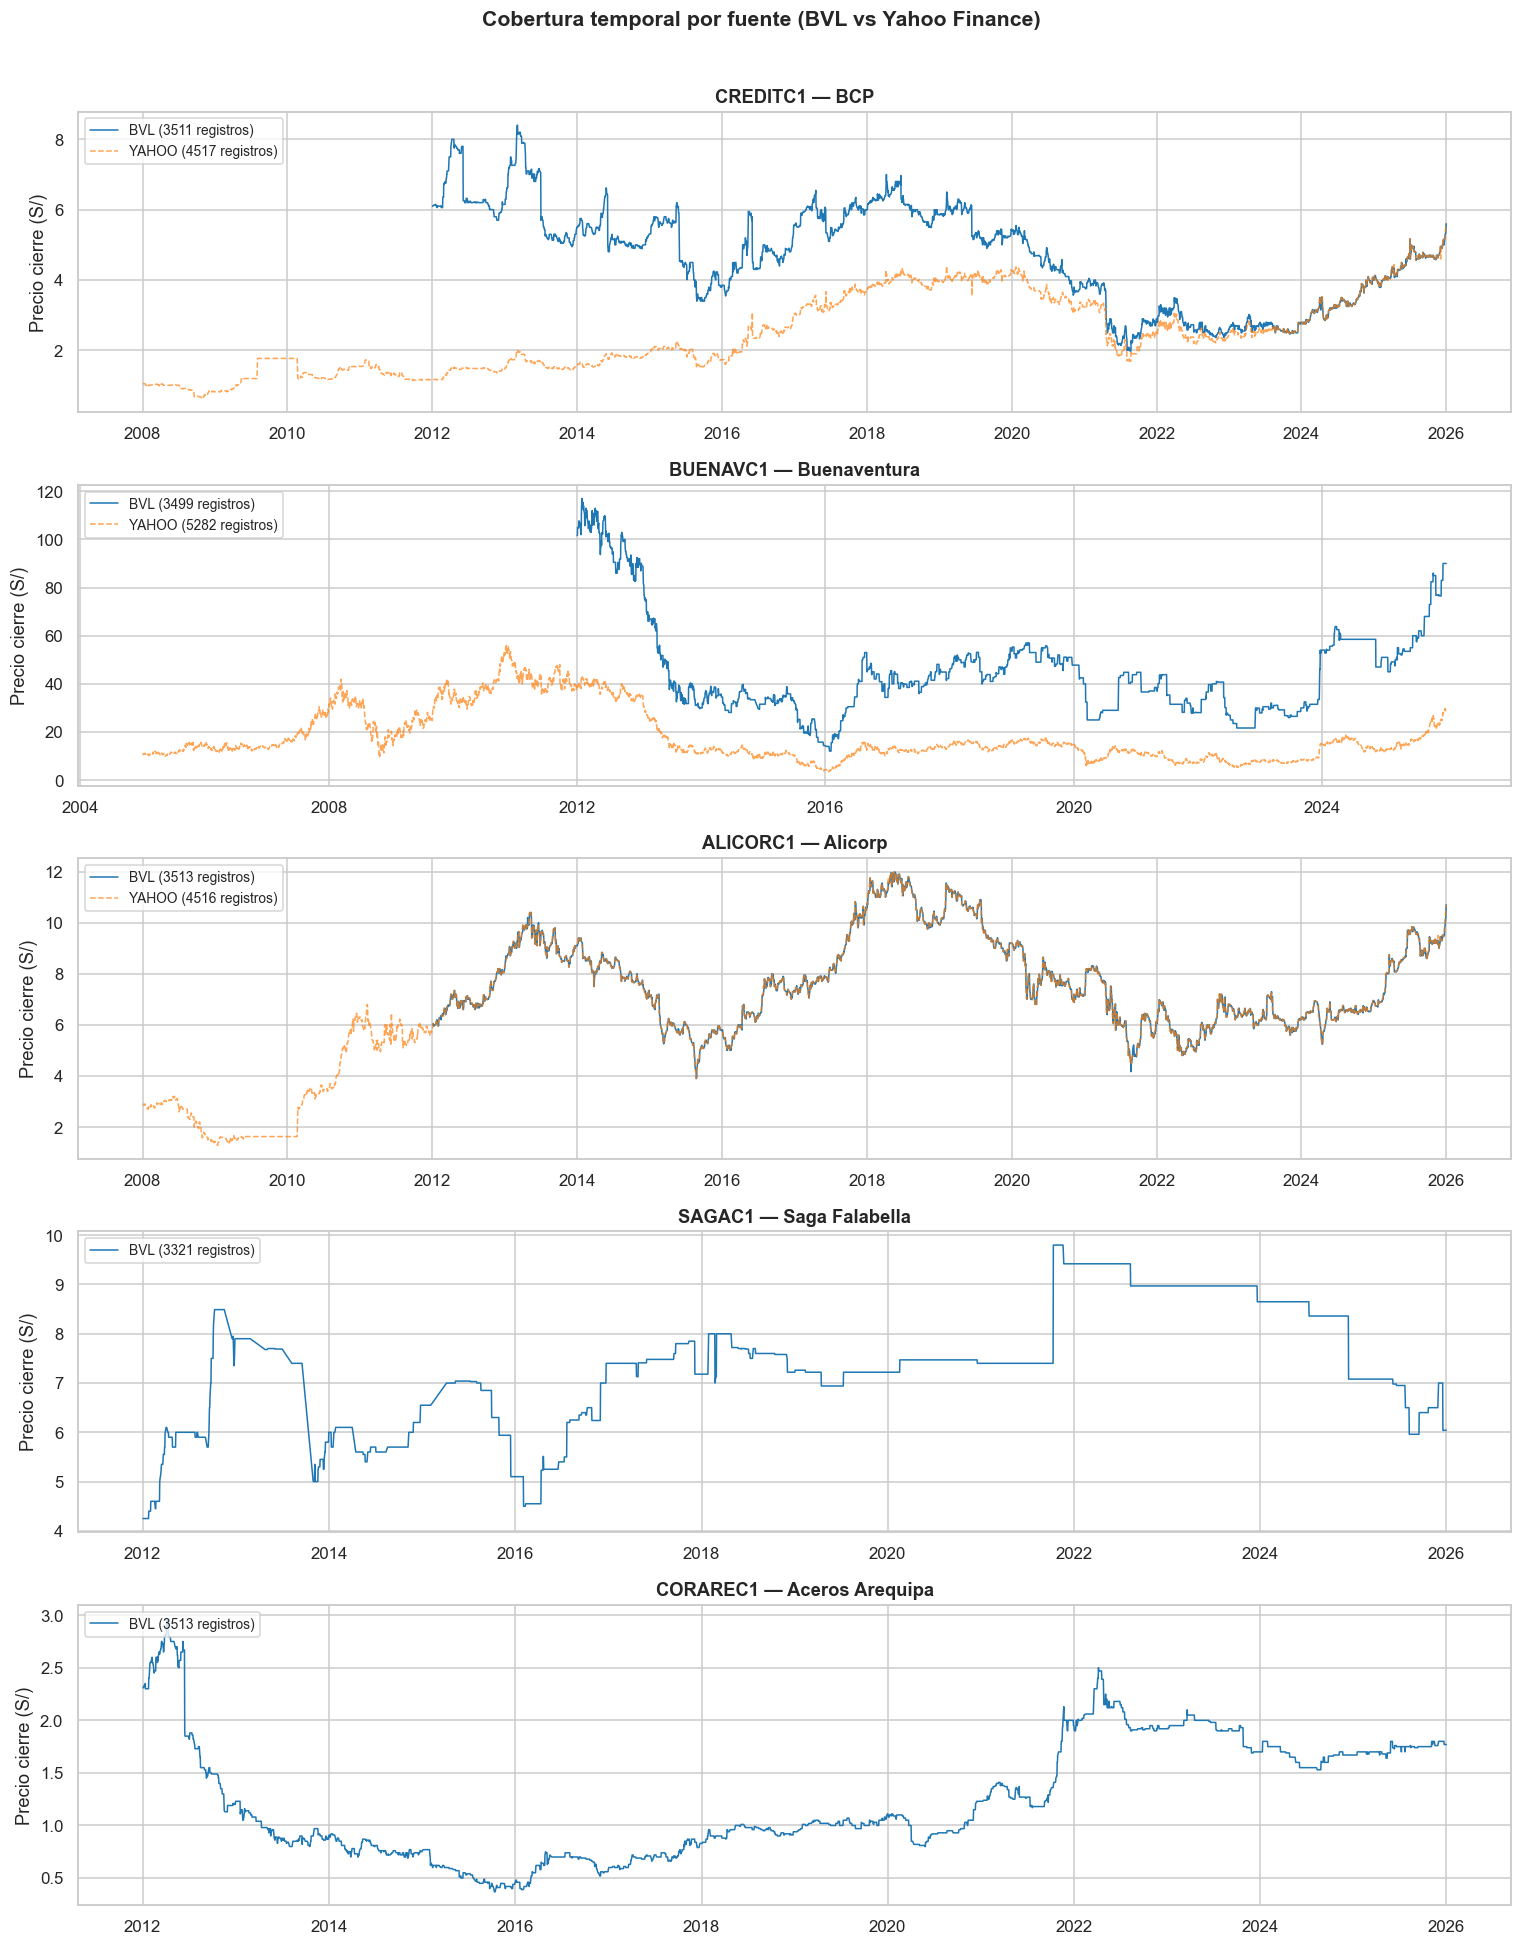

In [4]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 3.5 * len(TICKERS)), sharex=False)
fig.suptitle('Cobertura temporal por fuente (BVL vs Yahoo Finance)', fontsize=14, fontweight='bold', y=1.01)

for ax, ticker, color in zip(axes, TICKERS, COLORES):
    srcs = raw.get(ticker, {})
    plotted = False
    for src, df_src in srcs.items():
        df_src = df_src.copy()
        df_src['date'] = pd.to_datetime(df_src['date'])
        df_src = df_src.sort_values('date')
        label = f'{src.upper()} ({len(df_src)} registros)'
        ls = '-' if src == 'bvl' else '--'
        alpha = 1.0 if src == 'bvl' else 0.7
        ax.plot(df_src['date'], df_src['close'], linewidth=1, linestyle=ls, alpha=alpha, label=label)
        plotted = True
    if not plotted and ticker in interim:
        df_i = interim[ticker]
        ax.plot(df_i['date'], df_i['close'], linewidth=1, color=color, label='interim (fusionado)')
    ax.set_title(f'{ticker} — {NOMBRES[ticker]}', fontweight='bold')
    ax.set_ylabel('Precio cierre (S/)')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 4. Precios de cierre normalizados (base 100)

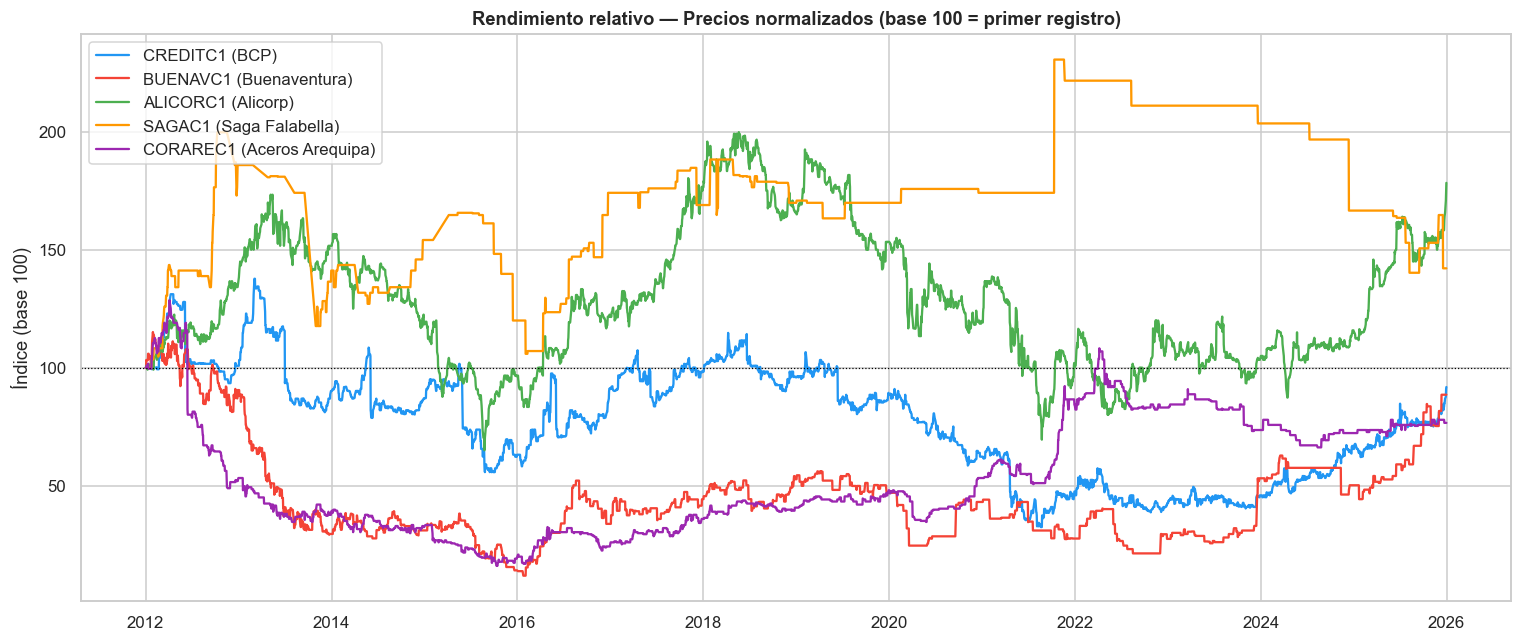

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

for ticker, color in zip(TICKERS, COLORES):
    df = interim.get(ticker)
    if df is None:
        continue
    base = df['close'].iloc[0]
    ax.plot(df['date'], df['close'] / base * 100,
            label=f'{ticker} ({NOMBRES[ticker]})', color=color, linewidth=1.5)

ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Rendimiento relativo — Precios normalizados (base 100 = primer registro)', fontweight='bold')
ax.set_ylabel('Índice (base 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 5. Indicadores técnicos por empresa

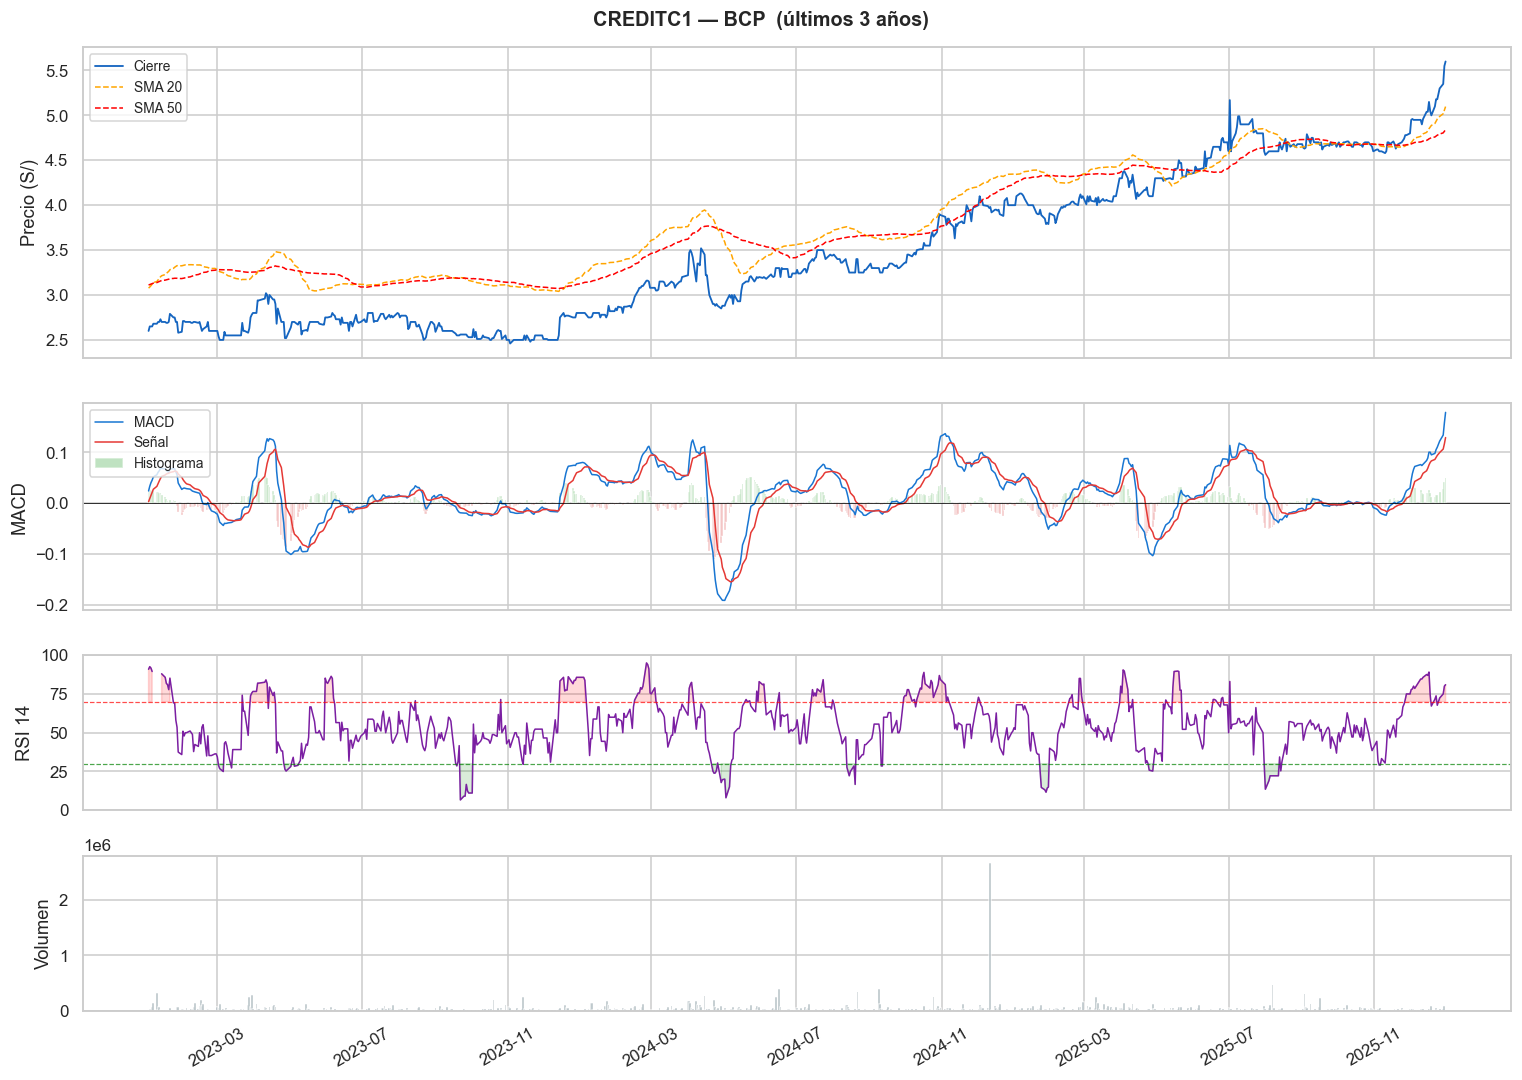

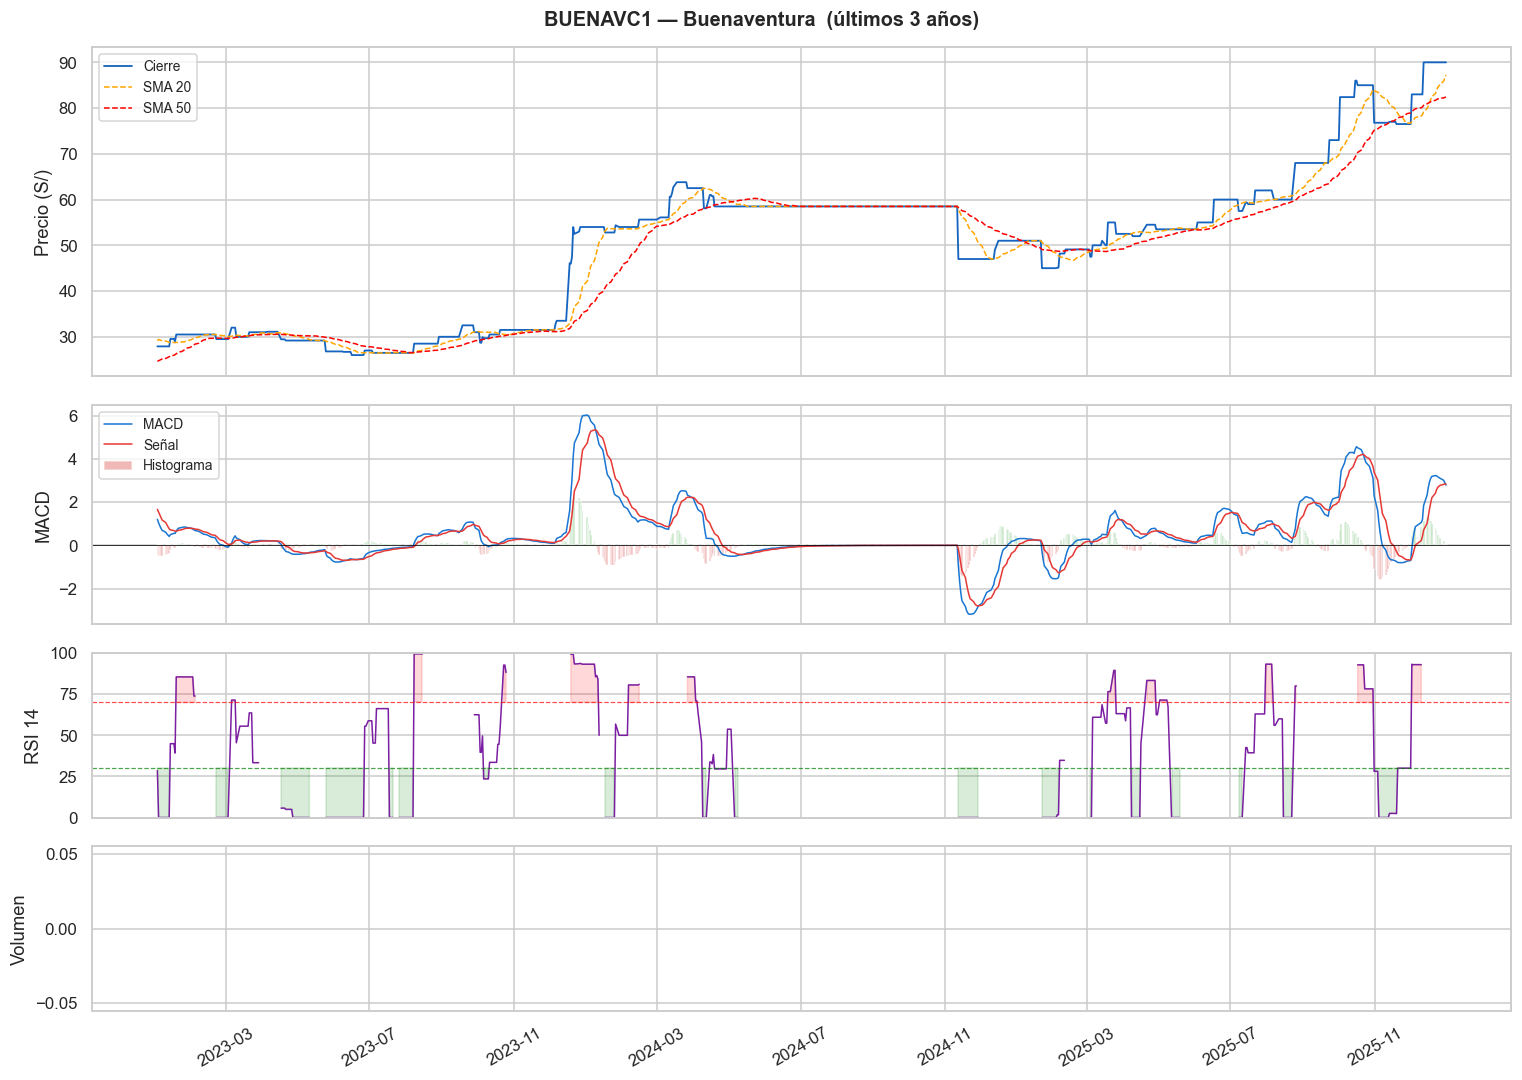

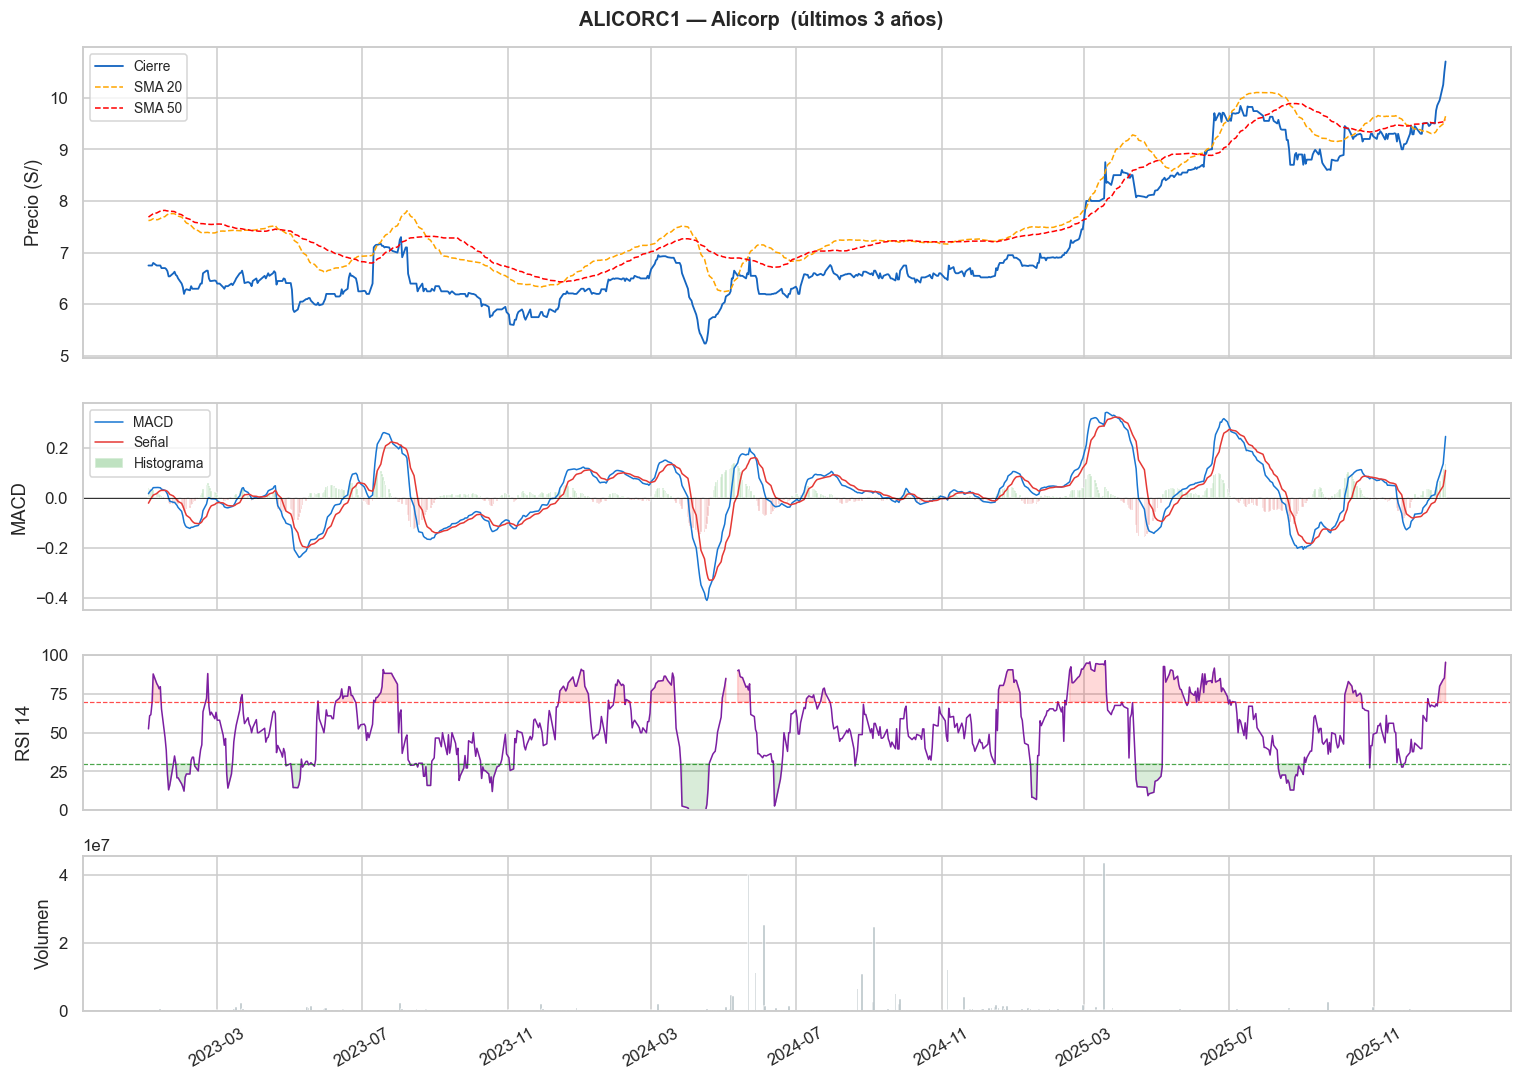

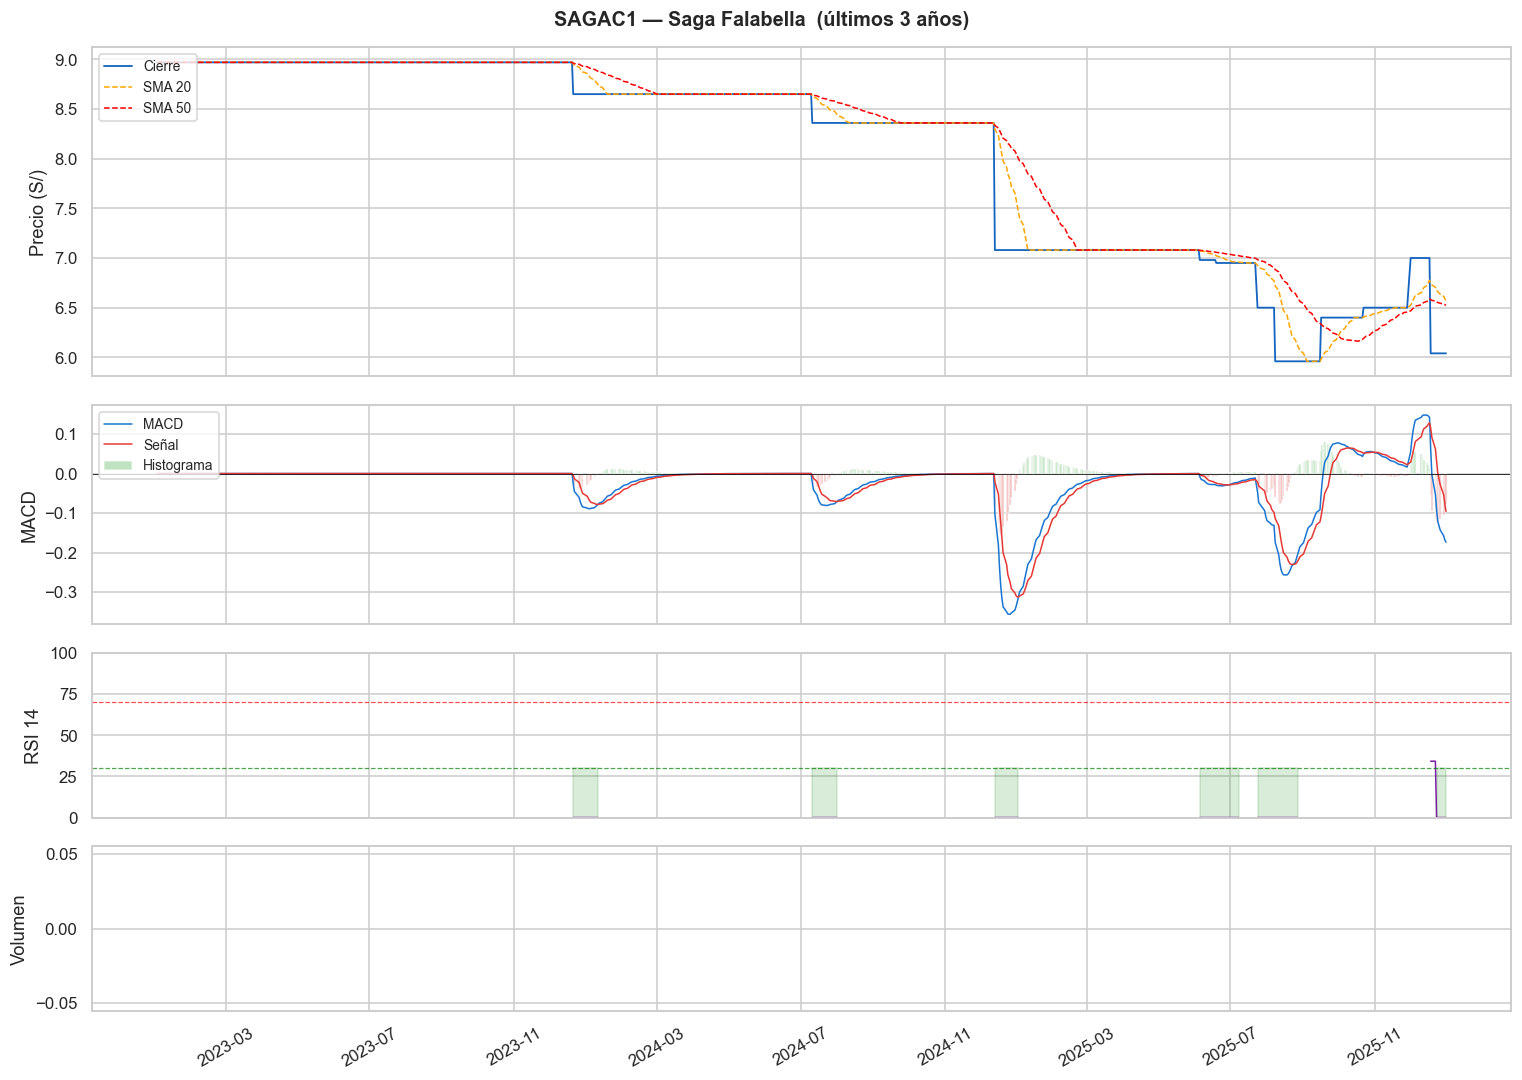

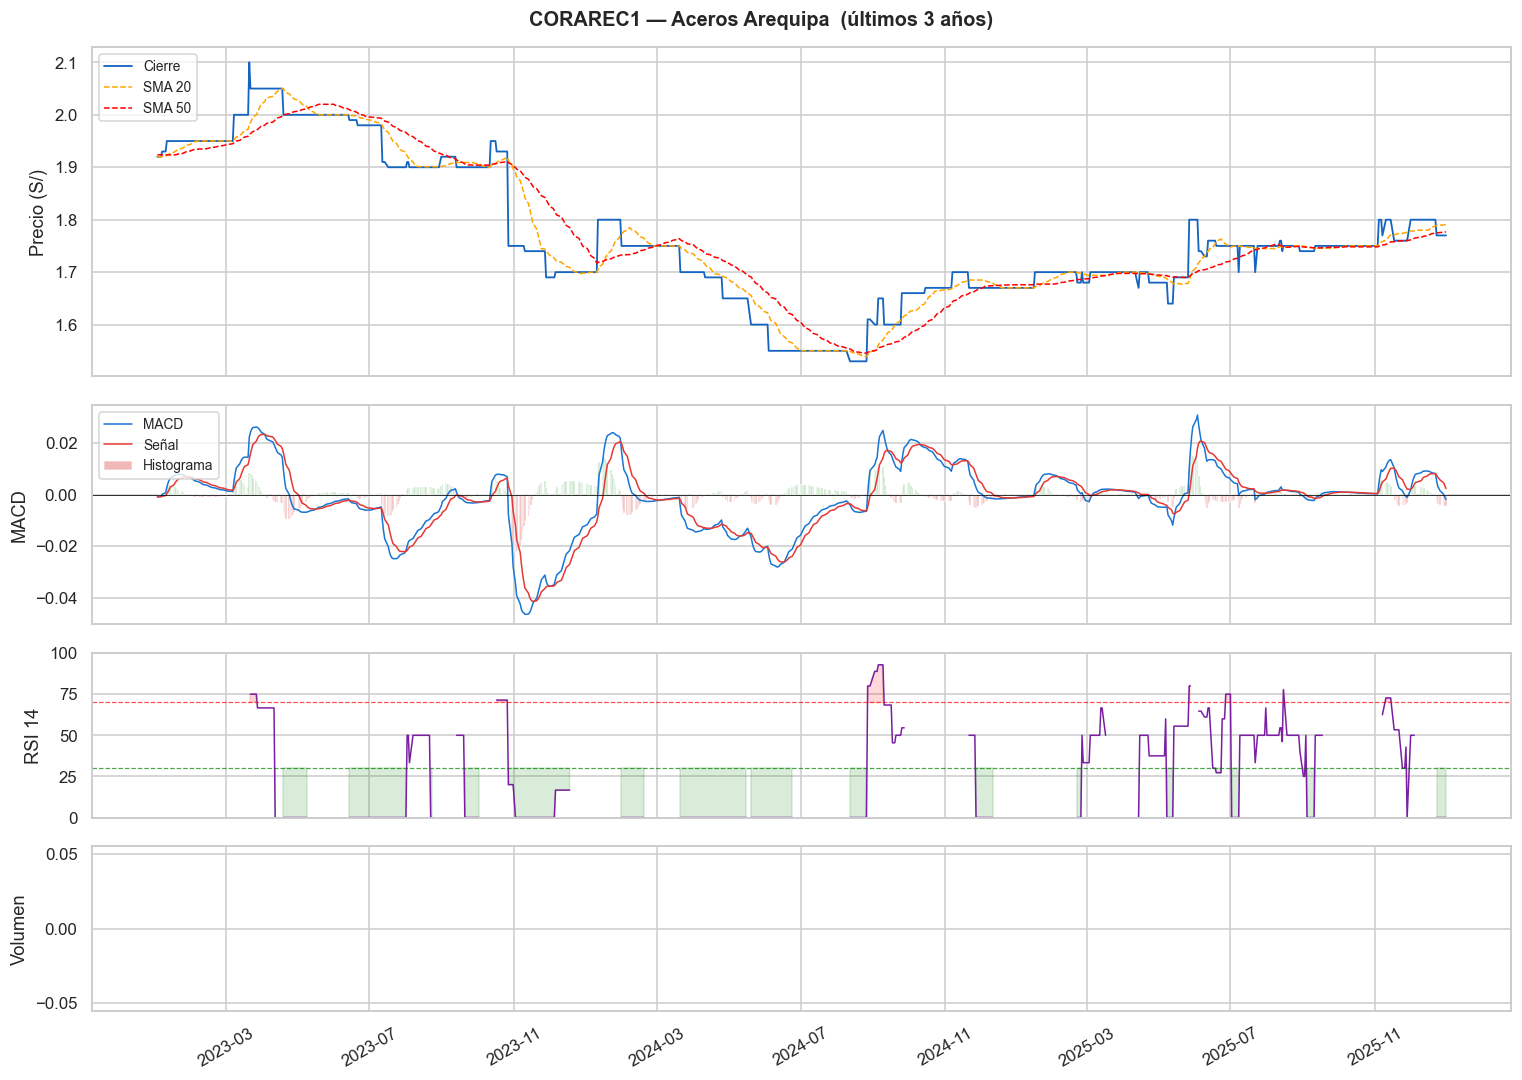

In [6]:
def plot_tecnico(ticker, df, ventana_años=3):
    """Panel de 4 subplots: Precio+SMA, MACD, RSI, Volumen."""
    fecha_fin = df['date'].max()
    fecha_ini = fecha_fin - pd.DateOffset(years=ventana_años)
    df = df[df['date'] >= fecha_ini].copy()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True,
                             gridspec_kw={'height_ratios': [3, 2, 1.5, 1.5]})
    fig.suptitle(f'{ticker} — {NOMBRES[ticker]}  (últimos {ventana_años} años)',
                 fontsize=13, fontweight='bold')

    # --- Precio + SMA ---
    ax = axes[0]
    ax.plot(df['date'], df['close'], color='#1565C0', linewidth=1.2, label='Cierre')
    if 'sma_20' in df: ax.plot(df['date'], df['sma_20'], '--', linewidth=1, color='orange', label='SMA 20')
    if 'sma_50' in df: ax.plot(df['date'], df['sma_50'], '--', linewidth=1, color='red',    label='SMA 50')
    ax.set_ylabel('Precio (S/)')
    ax.legend(loc='upper left', fontsize=9)

    # --- MACD ---
    ax = axes[1]
    if 'macd' in df and 'macd_signal' in df:
        ax.plot(df['date'], df['macd'],        color='#1976D2', linewidth=1, label='MACD')
        ax.plot(df['date'], df['macd_signal'], color='#E53935', linewidth=1, label='Señal')
        hist = df['macd'] - df['macd_signal']
        ax.bar(df['date'], hist, color=hist.apply(lambda x: '#81C784' if x >= 0 else '#E57373'),
               width=1.5, alpha=0.5, label='Histograma')
        ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('MACD')
    ax.legend(loc='upper left', fontsize=9)

    # --- RSI ---
    ax = axes[2]
    if 'rsi_14' in df:
        ax.plot(df['date'], df['rsi_14'], color='#7B1FA2', linewidth=1)
        ax.axhline(70, color='red',   linewidth=0.8, linestyle='--', alpha=0.7)
        ax.axhline(30, color='green', linewidth=0.8, linestyle='--', alpha=0.7)
        ax.fill_between(df['date'], df['rsi_14'], 70,
                        where=(df['rsi_14'] > 70), alpha=0.15, color='red')
        ax.fill_between(df['date'], df['rsi_14'], 30,
                        where=(df['rsi_14'] < 30), alpha=0.15, color='green')
        ax.set_ylim(0, 100)
    ax.set_ylabel('RSI 14')

    # --- Volumen ---
    ax = axes[3]
    ax.bar(df['date'], df['volume'], color='#546E7A', width=1.5, alpha=0.7)
    ax.set_ylabel('Volumen')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

for ticker in TICKERS:
    if ticker in interim:
        plot_tecnico(ticker, interim[ticker])

## 6. Distribución de retornos diarios

`ret_1d` se calcula sobre `close_total_return` (ver sección 9) — libre de los
saltos de splits/dividendos que sí aparecen en el precio crudo.

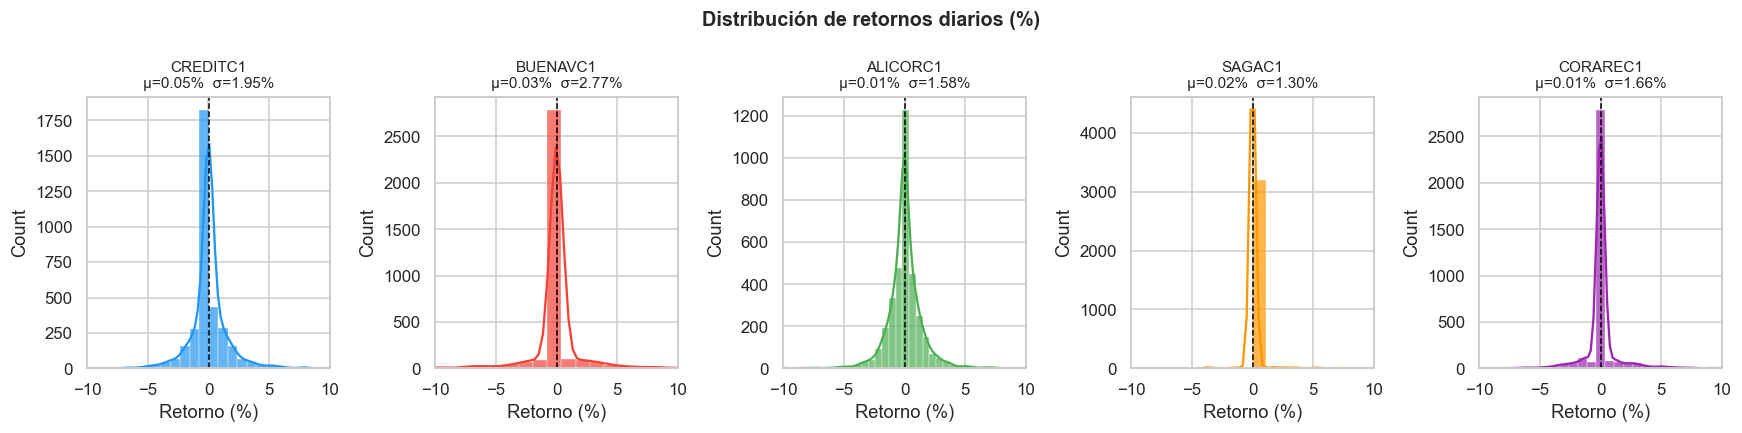

In [7]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 4), sharey=False)
fig.suptitle('Distribución de retornos diarios (%)', fontsize=13, fontweight='bold')

for ax, ticker, color in zip(axes, TICKERS, COLORES):
    df = interim.get(ticker)
    if df is None:
        continue
    col = 'ret_1d' if 'ret_1d' in df.columns else None
    if col is None:
        ret = df['close'].pct_change().dropna() * 100
    else:
        ret = df[col].dropna() * 100

    sns.histplot(ret, bins=60, kde=True, ax=ax, color=color, alpha=0.7)
    ax.axvline(ret.mean(), color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{ticker}\nμ={ret.mean():.2f}%  σ={ret.std():.2f}%', fontsize=10)
    ax.set_xlabel('Retorno (%)')
    ax.set_xlim(-10, 10)

plt.tight_layout()
plt.show()

## 7. Volatilidad anualizada (rolling 20 días)

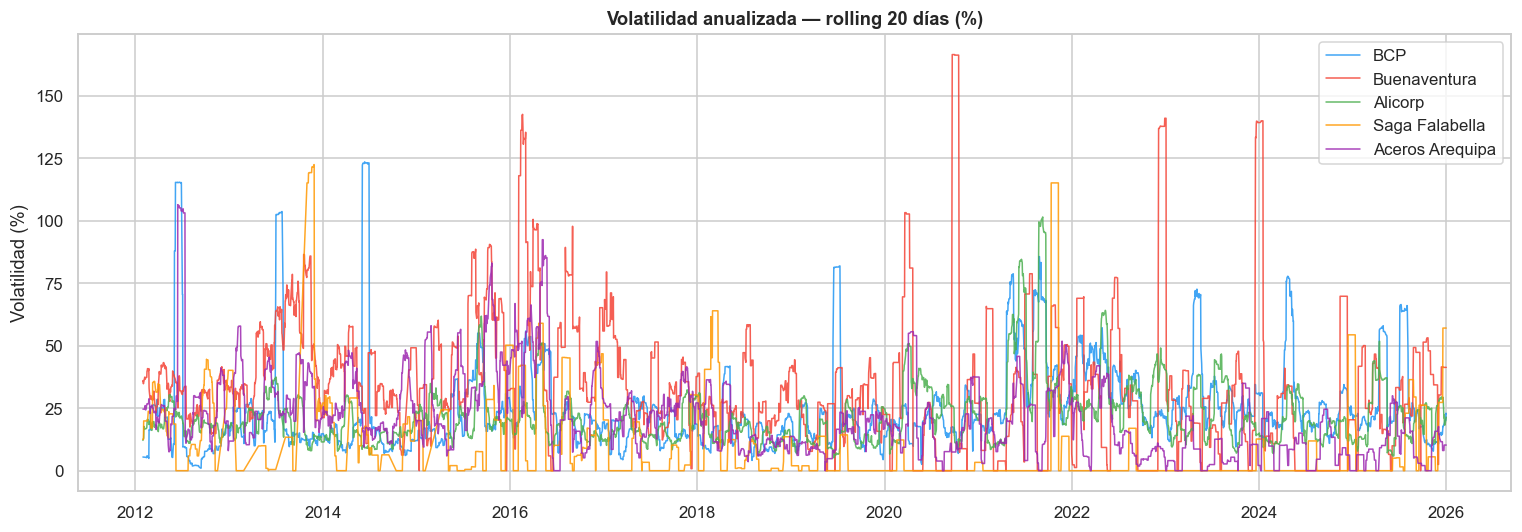

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

for ticker, color in zip(TICKERS, COLORES):
    df = interim.get(ticker)
    if df is None:
        continue
    col = 'volatility_20'
    if col in df.columns:
        ax.plot(df['date'], df[col] * 100, label=NOMBRES[ticker], color=color, linewidth=1, alpha=0.85)

ax.set_title('Volatilidad anualizada — rolling 20 días (%)', fontweight='bold')
ax.set_ylabel('Volatilidad (%)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 8. Correlación de retornos entre empresas

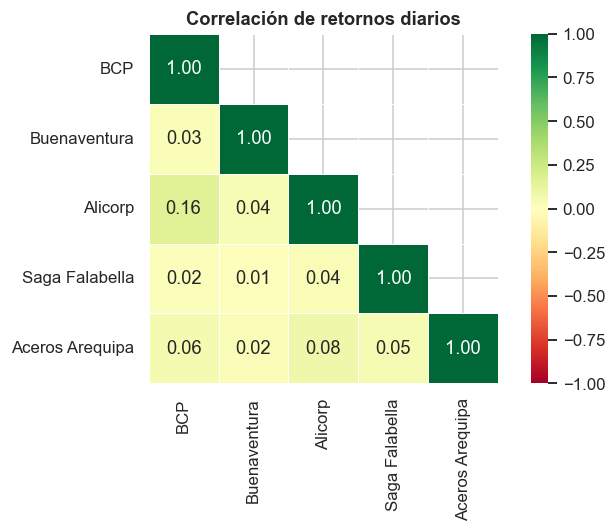


Estadísticas de retornos diarios:
             BCP  Buenaventura    Alicorp  Saga Falabella  Aceros Arequipa
count  3306.0000     3306.0000  3306.0000       3306.0000        3306.0000
mean      0.0006        0.0004     0.0002          0.0002           0.0002
std       0.0196        0.0275     0.0159          0.0130           0.0166
min      -0.2188       -0.2284    -0.2133         -0.3243          -0.2884
25%      -0.0025        0.0000    -0.0055          0.0000           0.0000
50%       0.0000        0.0000     0.0000          0.0000           0.0000
75%       0.0037        0.0000     0.0058          0.0000           0.0000
max       0.2507        0.4690     0.1207          0.3243           0.1613


In [9]:
retornos = {}
for ticker, df in interim.items():
    col = 'ret_1d' if 'ret_1d' in df.columns else None
    if col:
        s = df.set_index('date')[col].rename(NOMBRES[ticker])
    else:
        s = df.set_index('date')['close'].pct_change().rename(NOMBRES[ticker])
    retornos[NOMBRES[ticker]] = s

df_ret = pd.DataFrame(retornos).dropna()
corr = df_ret.corr()

fig, ax = plt.subplots(figsize=(7, 5))

import numpy as np
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, ax=ax,
            mask=mask, square=True, linewidths=0.5)
ax.set_title('Correlación de retornos diarios', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nEstadísticas de retornos diarios:")
print(df_ret.describe().round(4))

## 9. Acciones corporativas: close_raw vs close_split_adj vs close_total_return

Capa de ajuste por acciones corporativas (`src/market/corporate_actions.py`).
Para cada activo se calculan tres series de precio:

- **close_raw** — precio efectivamente negociado (= `close`).
- **close_split_adj** — ajustado por splits / acciones liberadas (convencion
  CRSP, ajuste hacia atras). Base para un P/E consistente con el EPS.
- **close_total_return** — ajustado por splits y dividendos reinvertidos. Es
  la serie sobre la que se calculan los indicadores tecnicos (`ret_1d`,
  `sma_*`, `rsi_14`, etc.) — la que ve el agente DRL.

CREDITC1 (BCP) distribuye acciones liberadas casi todos los anios, lo que
producia caidas artificiales de hasta -28% en `close_raw` de un dia para otro.
Esas caidas desaparecen en `close_split_adj`/`close_total_return`.

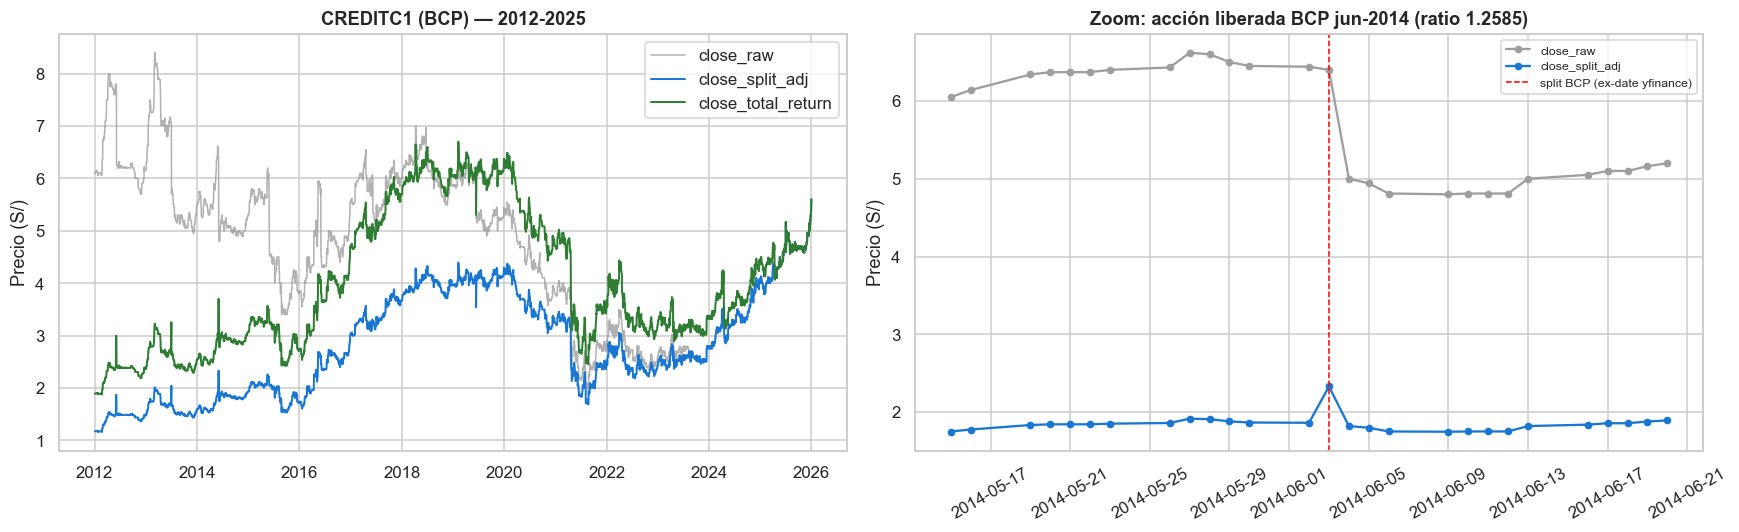

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df = interim['CREDITC1']

ax = axes[0]
ax.plot(df['date'], df['close_raw'], label='close_raw', linewidth=1, alpha=0.8, color='#9E9E9E')
ax.plot(df['date'], df['close_split_adj'], label='close_split_adj', linewidth=1.3, color='#1976D2')
ax.plot(df['date'], df['close_total_return'], label='close_total_return', linewidth=1.3, color='#2E7D32')
ax.set_title('CREDITC1 (BCP) — 2012-2025', fontweight='bold')
ax.set_ylabel('Precio (S/)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[1]
win = df[(df['date'] >= '2014-05-15') & (df['date'] <= '2014-06-20')]
ax.plot(win['date'], win['close_raw'], 'o-', label='close_raw', markersize=4, color='#9E9E9E')
ax.plot(win['date'], win['close_split_adj'], 'o-', label='close_split_adj', markersize=4, color='#1976D2')
ax.axvline(pd.Timestamp('2014-06-03'), color='red', linestyle='--', linewidth=1,
          label='split BCP (ex-date yfinance)')
ax.set_title('Zoom: acción liberada BCP jun-2014 (ratio 1.2585)', fontweight='bold')
ax.set_ylabel('Precio (S/)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

In [11]:
filas = []
for ticker, df in interim.items():
    for col in ['close_raw', 'close_split_adj', 'close_total_return']:
        ret = df.sort_values('date')[col].pct_change()
        filas.append({
            'Ticker': ticker, 'Serie': col,
            'max |ret|': ret.abs().max(),
            'n > 40%': int((ret.abs() > 0.40).sum()),
            'n > 100%': int((ret.abs() > 1.00).sum()),
        })
tabla = pd.DataFrame(filas)
orden_series = ['close_raw', 'close_split_adj', 'close_total_return']

print('Saltos diarios > 40% por serie (antes/despues del ajuste):')
display(tabla.pivot(index='Ticker', columns='Serie', values='n > 40%')[orden_series])

print()
print('Saltos diarios > 100% por serie:')
display(tabla.pivot(index='Ticker', columns='Serie', values='n > 100%')[orden_series])

print()
print('Retorno diario maximo absoluto por serie:')
display(tabla.pivot(index='Ticker', columns='Serie', values='max |ret|')[orden_series].round(3))

Saltos diarios > 40% por serie (antes/despues del ajuste):


Serie,close_raw,close_split_adj,close_total_return
Ticker,,,
ALICORC1,0,0,0
BUENAVC1,1,1,1
CORAREC1,0,0,0
CREDITC1,0,0,0
SAGAC1,0,0,0



Saltos diarios > 100% por serie:


Serie,close_raw,close_split_adj,close_total_return
Ticker,,,
ALICORC1,0,0,0
BUENAVC1,0,0,0
CORAREC1,0,0,0
CREDITC1,0,0,0
SAGAC1,0,0,0



Retorno diario maximo absoluto por serie:


Serie,close_raw,close_split_adj,close_total_return
Ticker,,,
ALICORC1,0.151,0.151,0.213
BUENAVC1,0.469,0.469,0.469
CORAREC1,0.288,0.288,0.288
CREDITC1,0.232,0.251,0.251
SAGAC1,0.324,0.324,0.324


In [12]:
flags = pd.DataFrame({
    ticker: df[['is_split_adjusted', 'is_div_adjusted']].iloc[0]
    for ticker, df in interim.items()
}).T
flags.index.name = 'Ticker'
print('Flags de ajuste por acciones corporativas:')
display(flags)

Flags de ajuste por acciones corporativas:


,is_split_adjusted,is_div_adjusted
Ticker,,
CREDITC1,True,True
BUENAVC1,False,False
ALICORC1,False,True
SAGAC1,False,False
CORAREC1,False,False


## 10. Vista de muestra — datos raw BVL

In [13]:
for ticker in TICKERS:
    for src in ('bvl', 'yahoo'):
        p = DATA_RAW / f'market_{ticker}_{src}.parquet'
        if p.exists():
            df = pd.read_parquet(p)
            print(f'\n=== {ticker} [{src.upper()}] — {len(df)} filas ===')
            display(df.tail(5))


=== CREDITC1 [BVL] — 3511 filas ===


,ticker,date,open,high,low,close,volume,source
3508,CREDITC1,2025-12-24,5.18,5.18,5.18,5.18,NaN,bvl
3509,CREDITC1,2025-12-26,5.30,5.30,5.30,5.30,NaN,bvl
3510,CREDITC1,2025-12-29,5.35,5.35,5.35,5.35,NaN,bvl
3511,CREDITC1,2025-12-30,5.55,5.55,5.55,5.55,NaN,bvl
3512,CREDITC1,2025-12-31,5.60,5.60,5.60,5.60,NaN,bvl



=== CREDITC1 [YAHOO] — 4517 filas ===


,ticker,date,open,high,low,close,volume,source
4512,CREDITC1,2025-12-23,5.20,5.20,5.18,5.18,46143,yahoo
4513,CREDITC1,2025-12-24,5.30,5.30,5.30,5.30,11317,yahoo
4514,CREDITC1,2025-12-26,5.39,5.39,5.35,5.35,23838,yahoo
4515,CREDITC1,2025-12-29,5.50,5.55,5.50,5.55,33333,yahoo
4516,CREDITC1,2025-12-30,5.60,5.60,5.60,5.60,78334,yahoo



=== BUENAVC1 [BVL] — 3499 filas ===


...

,ticker,date,open,high,low,close,volume,source
4511,ALICORC1,2025-12-23,9.8,9.85,9.80,9.85,13896,yahoo
4512,ALICORC1,2025-12-24,10.0,10.00,9.95,9.95,7216,yahoo
4513,ALICORC1,2025-12-26,10.0,10.25,10.00,10.25,21255,yahoo
4514,ALICORC1,2025-12-29,10.5,10.50,10.50,10.50,18801,yahoo
4515,ALICORC1,2025-12-30,10.5,10.70,10.50,10.70,23994,yahoo



=== SAGAC1 [BVL] — 3321 filas ===


,ticker,date,open,high,low,close,volume,source
3508,SAGAC1,2025-12-24,6.04,6.04,6.04,6.04,NaN,bvl
3509,SAGAC1,2025-12-26,6.04,6.04,6.04,6.04,NaN,bvl
3510,SAGAC1,2025-12-29,6.04,6.04,6.04,6.04,NaN,bvl
3511,SAGAC1,2025-12-30,6.04,6.04,6.04,6.04,NaN,bvl
3512,SAGAC1,2025-12-31,6.04,6.04,6.04,6.04,NaN,bvl



=== CORAREC1 [BVL] — 3513 filas ===


,ticker,date,open,high,low,close,volume,source
3508,CORAREC1,2025-12-24,1.77,1.77,1.77,1.77,NaN,bvl
3509,CORAREC1,2025-12-26,1.77,1.77,1.77,1.77,NaN,bvl
3510,CORAREC1,2025-12-29,1.77,1.77,1.77,1.77,NaN,bvl
3511,CORAREC1,2025-12-30,1.77,1.77,1.77,1.77,NaN,bvl
3512,CORAREC1,2025-12-31,1.77,1.77,1.77,1.77,NaN,bvl


## 11. Vista de muestra — datos interim (con acciones corporativas + indicadores tecnicos)

In [14]:
for ticker, df in interim.items():
    print(f'=== {ticker} ({NOMBRES[ticker]}) -- {len(df)} filas ===')
    cols_show = [c for c in ['date','open','high','low','close','volume','source',
                              'close_raw','close_split_adj','close_total_return',
                              'is_split_adjusted','is_div_adjusted',
                              'ret_1d','ret_1d_raw','sma_20','sma_50','rsi_14','macd','volatility_20']
                 if c in df.columns]
    display(df[cols_show].tail(8).round(4))

=== CREDITC1 (BCP) -- 3511 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3503,2025-12-19,5.00,5.10,5.00,5.00,80334.0,bvl,5.00,5.00,5.00,True,True,-0.0099,-0.0099,4.8880,4.7516,67.1875,0.0951,0.1764
3504,2025-12-22,5.10,5.18,5.10,5.10,13980.0,bvl,5.10,5.10,5.10,True,True,0.0200,0.0200,4.9100,4.7594,71.6216,0.0979,0.1853
3505,2025-12-23,5.20,5.20,5.18,5.18,46143.0,bvl,5.18,5.18,5.18,True,True,0.0157,0.0157,4.9350,4.7688,73.7500,0.1054,0.1894
3506,2025-12-24,5.30,5.30,5.30,5.18,11317.0,bvl,5.18,5.18,5.18,True,True,0.0000,0.0000,4.9590,4.7794,67.6923,0.1101,0.1903
3507,2025-12-26,5.39,5.39,5.35,5.30,23838.0,bvl,5.30,5.30,5.30,True,True,0.0232,0.0232,4.9880,4.7924,72.3684,0.1221,0.2009
3508,2025-12-29,5.50,5.55,5.50,5.35,33333.0,bvl,5.35,5.35,5.35,True,True,0.0094,0.0094,5.0185,4.8054,75.0000,0.1340,0.2012
3509,2025-12-30,5.60,5.60,5.60,5.55,78334.0,bvl,5.55,5.55,5.55,True,True,0.0374,0.0374,5.0570,4.8224,80.0000,0.1579,0.2298
3510,2025-12-31,5.60,5.60,5.60,5.60,NaN,bvl,5.60,5.60,5.60,True,True,0.0090,0.0090,5.0980,4.8404,80.9524,0.1787,0.2281


=== BUENAVC1 (Buenaventura) -- 3499 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3491,2025-12-19,90.0,90.0,90.0,90.0,NaN,bvl,90.0,90.0,90.0,False,False,0.0,0.0,82.5040,81.546,NaN,3.1939,0.4133
3492,2025-12-22,90.0,90.0,90.0,90.0,NaN,bvl,90.0,90.0,90.0,False,False,0.0,0.0,83.1785,81.698,NaN,3.2290,0.4133
3493,2025-12-23,90.0,90.0,90.0,90.0,NaN,bvl,90.0,90.0,90.0,False,False,0.0,0.0,83.8530,81.850,NaN,3.2198,0.4133
3494,2025-12-24,90.0,90.0,90.0,90.0,NaN,bvl,90.0,90.0,90.0,False,False,0.0,0.0,84.5275,82.002,NaN,3.1758,0.4133
3495,2025-12-26,90.0,90.0,90.0,90.0,NaN,bvl,90.0,90.0,90.0,False,False,0.0,0.0,85.2020,82.154,NaN,3.1052,0.4133
3496,2025-12-29,90.0,90.0,90.0,90.0,NaN,bvl,90.0,90.0,90.0,False,False,0.0,0.0,85.8765,82.234,NaN,3.0145,0.4133
3497,2025-12-30,90.0,90.0,90.0,90.0,NaN,bvl,90.0,90.0,90.0,False,False,0.0,0.0,86.5510,82.314,NaN,2.9090,0.4133
3498,2025-12-31,90.0,90.0,90.0,90.0,NaN,bvl,90.0,90.0,90.0,False,False,0.0,0.0,87.2255,82.414,NaN,2.7933,0.4133


=== ALICORC1 (Alicorp) -- 3513 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3505,2025-12-19,8.9914,8.9914,8.7609,9.51,18126.0,bvl,9.51,9.51,9.51,False,True,0.0042,0.0042,9.3045,9.5147,67.8261,0.0068,0.2934
3506,2025-12-22,8.8992,8.9914,8.8992,9.50,33725.0,bvl,9.50,9.50,9.50,False,True,-0.0011,-0.0011,9.3220,9.5089,66.6667,0.0122,0.2111
3507,2025-12-23,9.0376,9.0837,9.0376,9.75,13896.0,bvl,9.75,9.75,9.75,False,True,0.0263,0.0263,9.3445,9.5081,68.5950,0.0362,0.2228
3508,2025-12-24,9.2220,9.2220,9.1759,9.85,7216.0,bvl,9.85,9.85,9.85,False,True,0.0103,0.0103,9.3870,9.5122,67.2414,0.0626,0.1823
3509,2025-12-26,9.2220,9.4526,9.2220,9.95,21255.0,bvl,9.95,9.95,9.95,False,True,0.0102,0.0102,9.4345,9.5195,80.0000,0.0906,0.1825
3510,2025-12-29,9.6831,9.6831,9.6831,10.25,18801.0,bvl,10.25,10.25,10.25,False,True,0.0302,0.0302,9.4920,9.5318,84.2857,0.1353,0.2023
3511,2025-12-30,9.6831,9.8675,9.6831,10.50,23994.0,bvl,10.50,10.50,10.50,False,True,0.0244,0.0244,9.5620,9.5492,85.2349,0.1888,0.2109
3512,2025-12-31,10.7000,10.7000,10.7000,10.70,NaN,bvl,10.70,10.70,10.70,False,True,0.0190,0.0190,9.6410,9.5698,95.4545,0.2445,0.2140


=== SAGAC1 (Saga Falabella) -- 3321 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3313,2025-12-19,6.04,6.04,6.04,6.04,NaN,bvl,6.04,6.04,6.04,False,False,0.0,0.0,6.729,6.5736,34.2466,-0.0026,0.5706
3314,2025-12-22,6.04,6.04,6.04,6.04,NaN,bvl,6.04,6.04,6.04,False,False,0.0,0.0,6.706,6.5664,34.2466,-0.0527,0.5706
3315,2025-12-23,6.04,6.04,6.04,6.04,NaN,bvl,6.04,6.04,6.04,False,False,0.0,0.0,6.683,6.5592,0.0000,-0.0913,0.5706
3316,2025-12-24,6.04,6.04,6.04,6.04,NaN,bvl,6.04,6.04,6.04,False,False,0.0,0.0,6.660,6.5520,0.0000,-0.1205,0.5706
3317,2025-12-26,6.04,6.04,6.04,6.04,NaN,bvl,6.04,6.04,6.04,False,False,0.0,0.0,6.637,6.5448,0.0000,-0.1421,0.5706
3318,2025-12-29,6.04,6.04,6.04,6.04,NaN,bvl,6.04,6.04,6.04,False,False,0.0,0.0,6.614,6.5376,0.0000,-0.1573,0.5706
3319,2025-12-30,6.04,6.04,6.04,6.04,NaN,bvl,6.04,6.04,6.04,False,False,0.0,0.0,6.591,6.5304,0.0000,-0.1675,0.5706
3320,2025-12-31,6.04,6.04,6.04,6.04,NaN,bvl,6.04,6.04,6.04,False,False,0.0,0.0,6.568,6.5232,0.0000,-0.1735,0.5706


=== CORAREC1 (Aceros Arequipa) -- 3513 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3505,2025-12-19,1.80,1.80,1.80,1.80,NaN,bvl,1.80,1.80,1.80,False,False,0.0000,0.0000,1.7860,1.7734,NaN,0.0085,0.0807
3506,2025-12-22,1.80,1.80,1.80,1.80,NaN,bvl,1.80,1.80,1.80,False,False,0.0000,0.0000,1.7880,1.7744,NaN,0.0081,0.0807
3507,2025-12-23,1.77,1.77,1.77,1.77,NaN,bvl,1.77,1.77,1.77,False,False,-0.0167,-0.0167,1.7885,1.7748,0.0,0.0054,0.1025
3508,2025-12-24,1.77,1.77,1.77,1.77,NaN,bvl,1.77,1.77,1.77,False,False,0.0000,0.0000,1.7890,1.7752,0.0,0.0032,0.1025
3509,2025-12-26,1.77,1.77,1.77,1.77,NaN,bvl,1.77,1.77,1.77,False,False,0.0000,0.0000,1.7895,1.7756,0.0,0.0015,0.1025
3510,2025-12-29,1.77,1.77,1.77,1.77,NaN,bvl,1.77,1.77,1.77,False,False,0.0000,0.0000,1.7900,1.7760,0.0,0.0001,0.1025
3511,2025-12-30,1.77,1.77,1.77,1.77,NaN,bvl,1.77,1.77,1.77,False,False,0.0000,0.0000,1.7905,1.7764,0.0,-0.0010,0.1025
3512,2025-12-31,1.77,1.77,1.77,1.77,NaN,bvl,1.77,1.77,1.77,False,False,0.0000,0.0000,1.7910,1.7768,0.0,-0.0019,0.1025
